# Preparação para Atividade Avaliativa - Treinamento de MLPs e CNNs

O objetivo desta atividade é se preparar para a atividade avaliativa. Para isto, seleciona uma das bases de dados utilizadas anteriormente (mnist, doenças em folhas de feijão ou raios-x) e siga os passos indicados abaixo. Em caso de dúvida, veja o notebook que demonstra como treinar CNNs. 

**Importante**: Use o google colab para treinar as CNNs usando GPUs.


---

Imports básicos

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision.datasets import ImageFolder

sns.set_style('darkgrid')


### Obtenção dos Dados

Obtenha os dados usando a biblioteca kagglehub ou lendo os dados do disco.

In [2]:
# resposta
import kagglehub

ds_path = kagglehub.dataset_download("marquis03/bean-leaf-lesions-classification")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
ds_path

/home/Heitor-Guerra/IdeaProjects/Redes_Neurais/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


'/home/Heitor-Guerra/.cache/kagglehub/datasets/marquis03/bean-leaf-lesions-classification/versions/1'

### Construção do Dataset do Pytorch

Implemente uma classe para representar o dataset do pytorch ou usa função pré-defina como [ImageFolder](https://debuggercafe.com/pytorch-imagefolder-for-training-cnn-models/).

A classe deve receber como entrada um atributo `transform` que realize pré-processamento nos dados e *data augmentation* no treino.


In [3]:
# resposta
import torchvision.transforms.v2 as v2
from torchvision.datasets import ImageFolder
import os

train_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize((128,128)),

    v2.RandAugment(3),

    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((128, 128)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5,0.5,0.5], std=[0.5,0.5,0.5])
])


train_ds = ImageFolder(os.path.join(ds_path, "train"), transform=train_transform)
test_ds = ImageFolder(os.path.join(ds_path, "val"), transform=test_transform)

print(len(train_ds))
print(len(test_ds))

1034
133


### Construção do Dataloader e Visualização de Exemplos

Crie dataloaders.

In [4]:
# resposta

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

train_loader

Mostra algumas imagens de exemplo.

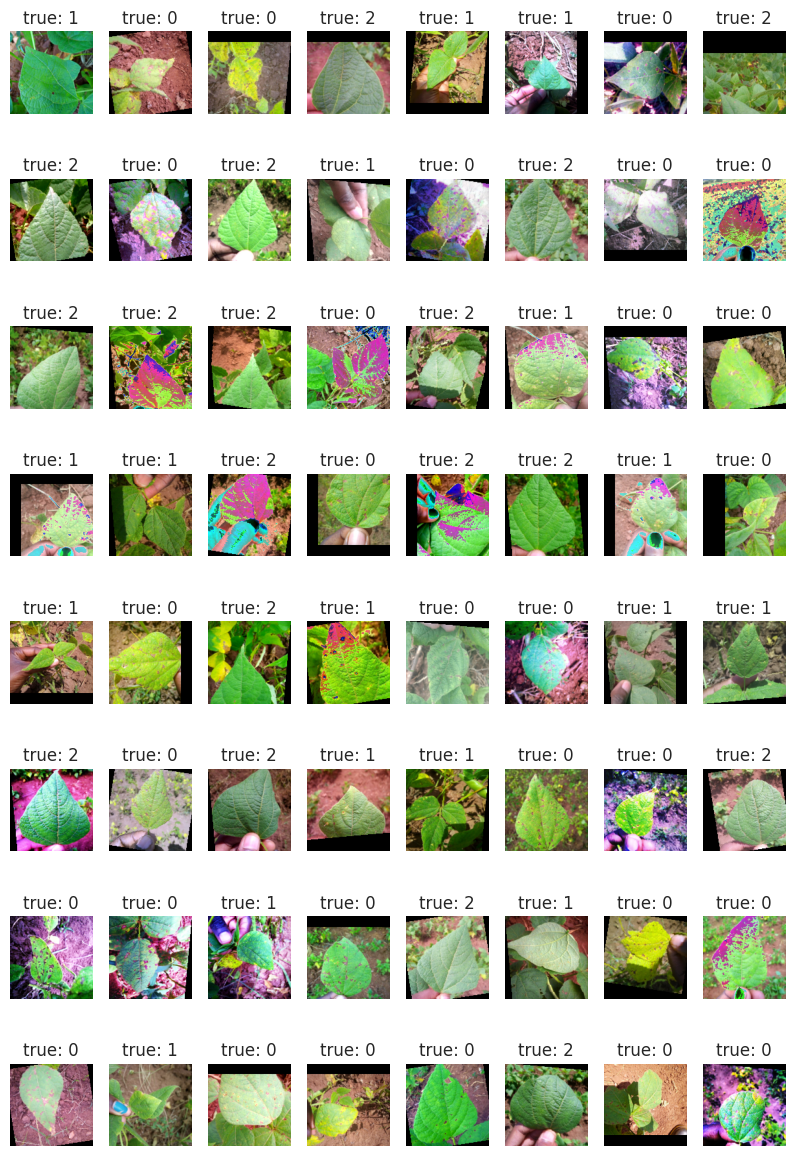

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(images, labels):
    n = len(images)
    grid_size = int(np.ceil(np.sqrt(n)))

    for idx in range(n):
        plt.subplot(grid_size, grid_size, idx + 1)
        img = images[idx].numpy()

        # muda do formato [channels, rows, cols] do torch para [rows, cols, channels]
        img = np.transpose(img, (1, 2, 0))
        img -= img.min()
        img /= img.max()

        plt.imshow(img)
        plt.grid(False)
        plt.axis('off')
        title = f'true: {labels[idx].numpy()}'
        plt.title(title)

# get some random training images
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.close('all')
plt.figure(figsize=(10, 15))
show_batch(images, labels)
plt.show()


### Definição do Modelo

Construa uma rede MLP usando `nn.Sequential`.

In [6]:
# resposta

mlp = nn.Sequential(
    nn.Flatten(),

    nn.Linear(128*128*3, 256),
    nn.ReLU(),

    nn.Linear(256, 256),
    nn.ReLU(),

    nn.Linear(256, 3)
)

mlp = mlp.to(device)

mlp

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=49152, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=256, bias=True)
  (4): ReLU()
  (5): Linear(in_features=256, out_features=3, bias=True)
)

Construa uma rede convolucional usando `nn.Sequential`.

In [52]:
# resposta

# out = floor(input - kernel_size + 2padding)/stride + 1

cnn = nn.Sequential(
    nn.Conv2d(3, 32, 5),  # 32*124*124
    nn.ReLU(),
    nn.MaxPool2d(2, 2),   # 32*62*62

    nn.Conv2d(32, 64, 5), # 64*58*58
    nn.ReLU(),
    nn.MaxPool2d(2, 2),   # 64*29*29

    nn.Conv2d(64, 64, 5), # 64*25*25
    nn.ReLU(),
    nn.MaxPool2d(2, 2),   # 64*12*12

    nn.Flatten(),

    nn.Linear(64*12*12, 128),
    nn.ReLU(),

    nn.Dropout(0.2),
    nn.Linear(128, 3),
)

cnn = cnn.to(device)

cnn

Sequential(
  (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=9216, out_features=128, bias=True)
  (11): ReLU()
  (12): Dropout(p=0.2, inplace=False)
  (13): Linear(in_features=128, out_features=3, bias=True)
)

Carregue uma rede pré-treinada e configure-a para *feature extraction*.

In [12]:
# resposta
import torchvision.models as models

fe = models.resnet101(weights="IMAGENET1K_V2")

for param in fe.parameters():
    param.requires_grad = False
ins = fe.fc.in_features
fe.fc = nn.Linear(ins, 3)

fe = fe.to(device)

fe

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

Carregue uma rede pré-treinada e configure-a para *fine-tuning*.

In [16]:
# resposta

ft = models.resnet101(weights="IMAGENET1K_V2")

ft.classifier = nn.Linear(ins, 3)

ft = ft.to(device)
ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

### Treinamento e Avaliação

Escreva uma função para treinamento do modelo que receba como entrada o modelo, o dataloader de treino, o otimizador, a função de perda e o número de épocas. A função deve mostrar na tela como a acurácia evoluiu ao longo do treinamento.

In [8]:
# resposta

from sklearn.metrics import accuracy_score

loss = nn.CrossEntropyLoss()

def train(model, dataloader, optimizer, criterion, n_epochs):
    acc_history = []
    loss_history = []

    model.train()
    for i in range(n_epochs):
        all_labels = []
        all_preds = []
        all_loss = []

        for batch in dataloader:
            data, labels = batch
            all_labels.extend(labels)
            data = data.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(data)

            loss = criterion(outputs, labels)
            loss.backward()


            all_loss.append(loss.cpu().detach().numpy())

            optimizer.step()

            all_preds.extend(list(np.argmax(outputs.cpu().detach().numpy(), axis=-1)))
        acc = accuracy_score(all_labels, all_preds)
        loss_history.append(np.mean(all_loss))
        acc_history.append(acc)
        print(acc)
    return acc_history, loss_history

Escreva uma função para avaliação do modelo que receba como entrada o modelo e o dataloader de teste. A função deve mostrar na tela as métricas de acurácia, precision, recall e f1-score. 

In [17]:
# resposta

from sklearn.metrics import classification_report

def evaluation(model, dataloader):
    all_labels = []
    all_preds = []
    model.eval()
    with torch.no_grad():
      for batch in dataloader:
        data, labels = batch
        all_labels.extend(labels)
        data = data.to(device)

        outputs = model(data)
        all_preds.extend(list(np.argmax(outputs.cpu().numpy(), axis=-1)))
    print(classification_report(all_labels, all_preds))


Use as funções para treinar e avaliar a rede MLP.


In [57]:
# resposta

mlp_optim = optim.Adam(mlp.parameters(), 1e-3)
acc_history, loss_history = train(mlp, train_loader, mlp_optim, loss, 20)
evaluation(mlp, test_loader)

0.3945841392649903
0.5106382978723404
0.558027079303675
0.5667311411992263
0.574468085106383
0.6092843326885881
0.6141199226305609
0.6121856866537717
0.6276595744680851
0.6266924564796905
0.6411992263056093
0.6334622823984526
0.6353965183752418
0.6470019342359767
0.6566731141199227
0.655705996131528
0.6576402321083172
0.6634429400386848
0.6789168278529981
0.7117988394584139
              precision    recall  f1-score   support

           0       0.60      0.68      0.64        44
           1       0.75      0.53      0.62        45
           2       0.75      0.86      0.80        44

    accuracy                           0.69       133
   macro avg       0.70      0.69      0.69       133
weighted avg       0.70      0.69      0.69       133



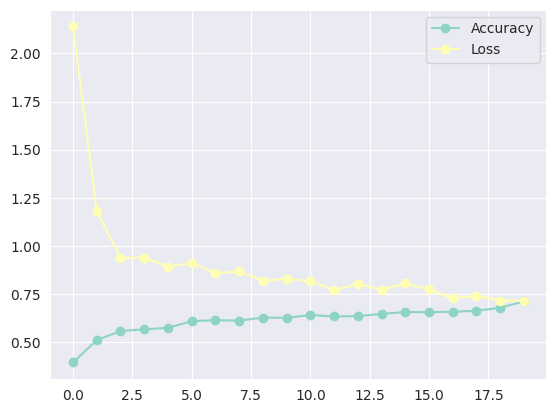

In [58]:
plt.plot(acc_history, "-o")
plt.plot(loss_history, "-o")
plt.legend(["Accuracy", "Loss"])

Use as funções para treinar e avaliar a CNN que você construiu.


In [59]:
# resposta


cnn_optim = optim.Adam(cnn.parameters(), 1e-3)
acc_history, loss_history = train(cnn, train_loader, cnn_optim, loss, 20)
evaluation(cnn, test_loader)


0.4071566731141199
0.5087040618955513
0.5493230174081238
0.5909090909090909
0.5880077369439072
0.6005802707930368
0.5667311411992263
0.6131528046421664
0.6179883945841392
0.625725338491296
0.6547388781431335
0.6353965183752418
0.6470019342359767
0.655705996131528
0.6760154738878144
0.6566731141199227
0.6856866537717602
0.6866537717601547
0.7137330754352031
0.7088974854932302
              precision    recall  f1-score   support

           0       0.82      0.61      0.70        44
           1       0.74      0.78      0.76        45
           2       0.75      0.91      0.82        44

    accuracy                           0.77       133
   macro avg       0.77      0.77      0.76       133
weighted avg       0.77      0.77      0.76       133



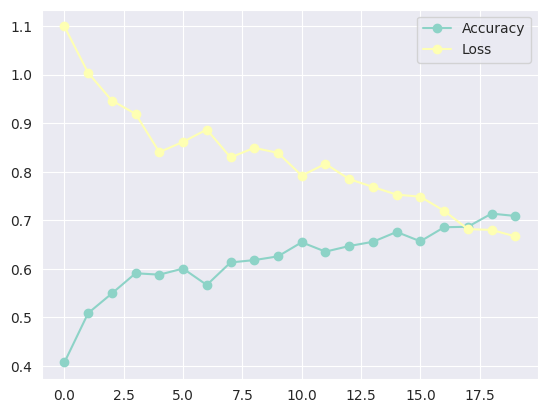

In [60]:
plt.plot(acc_history, "-o")
plt.plot(loss_history, "-o")
plt.legend(["Accuracy", "Loss"])

Use as funções para treinar e avaliar a CNN configurada para *feature extraction*. Lembre-se definir no otimizador que apenas as últimas camadas devem ser treinadas.


In [14]:
# resposta

fe_optim = optim.Adam(fe.fc.parameters(), 1e-3)
acc_history, loss_history = train(fe, train_loader, fe_optim, loss, 20)
evaluation(fe, test_loader)


0.5657640232108317
0.7321083172147002
0.7350096711798839
0.7630560928433269
0.7833655705996132
0.793036750483559
0.7872340425531915
0.811411992263056
0.8336557059961315
0.7969052224371374
0.811411992263056
0.8191489361702128
0.8375241779497099
0.8210831721470019
0.8191489361702128
0.8307543520309478
0.8588007736943907
0.8471953578336557
0.8597678916827853
0.8491295938104448
              precision    recall  f1-score   support

           0       0.86      0.70      0.78        44
           1       0.75      0.87      0.80        45
           2       0.89      0.91      0.90        44

    accuracy                           0.83       133
   macro avg       0.83      0.83      0.83       133
weighted avg       0.83      0.83      0.83       133



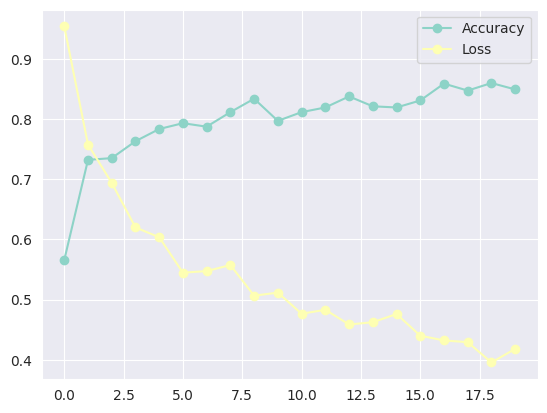

In [15]:
plt.plot(acc_history, "-o")
plt.plot(loss_history, "-o")
plt.legend(["Accuracy", "Loss"])


Use as funções para treinar e avaliar a CNN configurada para *fine-tuning*. 


In [18]:
# resposta
ft_optim = optim.Adam(ft.parameters(), 1e-3)
acc_history, loss_history = train(ft, train_loader, ft_optim, loss, 20)
evaluation(ft, test_loader)


0.5918762088974855
0.8762088974854932
0.925531914893617
0.9516441005802708
0.9690522243713733
0.9555125725338491
0.9555125725338491
0.965183752417795
0.9806576402321083
0.9738878143133463
0.9487427466150871
0.9593810444874274
0.971953578336557
0.9825918762088974
0.9729206963249516
0.9816247582205029
0.9816247582205029
0.9816247582205029
0.9613152804642167
0.9632495164410058
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        44
           1       1.00      0.89      0.94        45
           2       0.95      0.95      0.95        44

    accuracy                           0.95       133
   macro avg       0.95      0.95      0.95       133
weighted avg       0.95      0.95      0.95       133



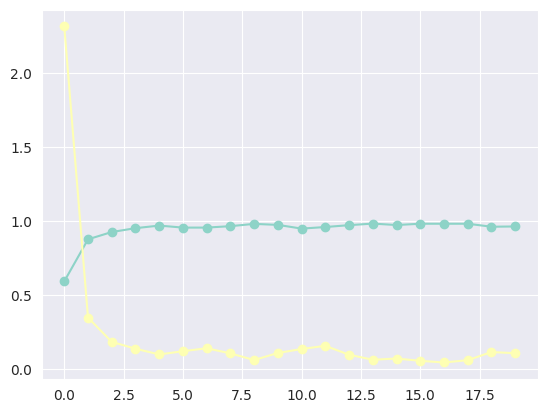

In [19]:
plt.plot(acc_history, "-o")
plt.plot(loss_history, "-o")

## Análise Crítica

Escreva um parágrafo discutindo os seguintes itens: 

1. Como a acurácia evoluiu ao longo do treinamento para os diferentes modelos? Quais modelos alcançaram uma boa performance no treino? Caso algum modelo tenha alcançado uma acurácia mais de 10% inferior aos demais, dê hipóteses que possam justificar este fenômeno.

2. Os modelos generalizaram? Qual modelo alcançou melhor performance no conjunto de teste? Qual modelo você escolheria para implantar em um ambiente real considerando a tarefa específica? Justifique sua escolha.

3. Explique como as métricas precision e recall por classe devem ser interpretadas e o que podemos concluir avaliando estes valores para os diferentes modelos, e.g., o modelo priorizou uma classe sobre as demais? Alguma classe é raramente selecionada pelo modelo? 




Adiciona sua resposta aqui...
